## GroupShuffleSplit

GroupShuffleSplit is used when your dataset contains groups of related samples, and you want all samples from the same group to stay together in either the training set or the test set.

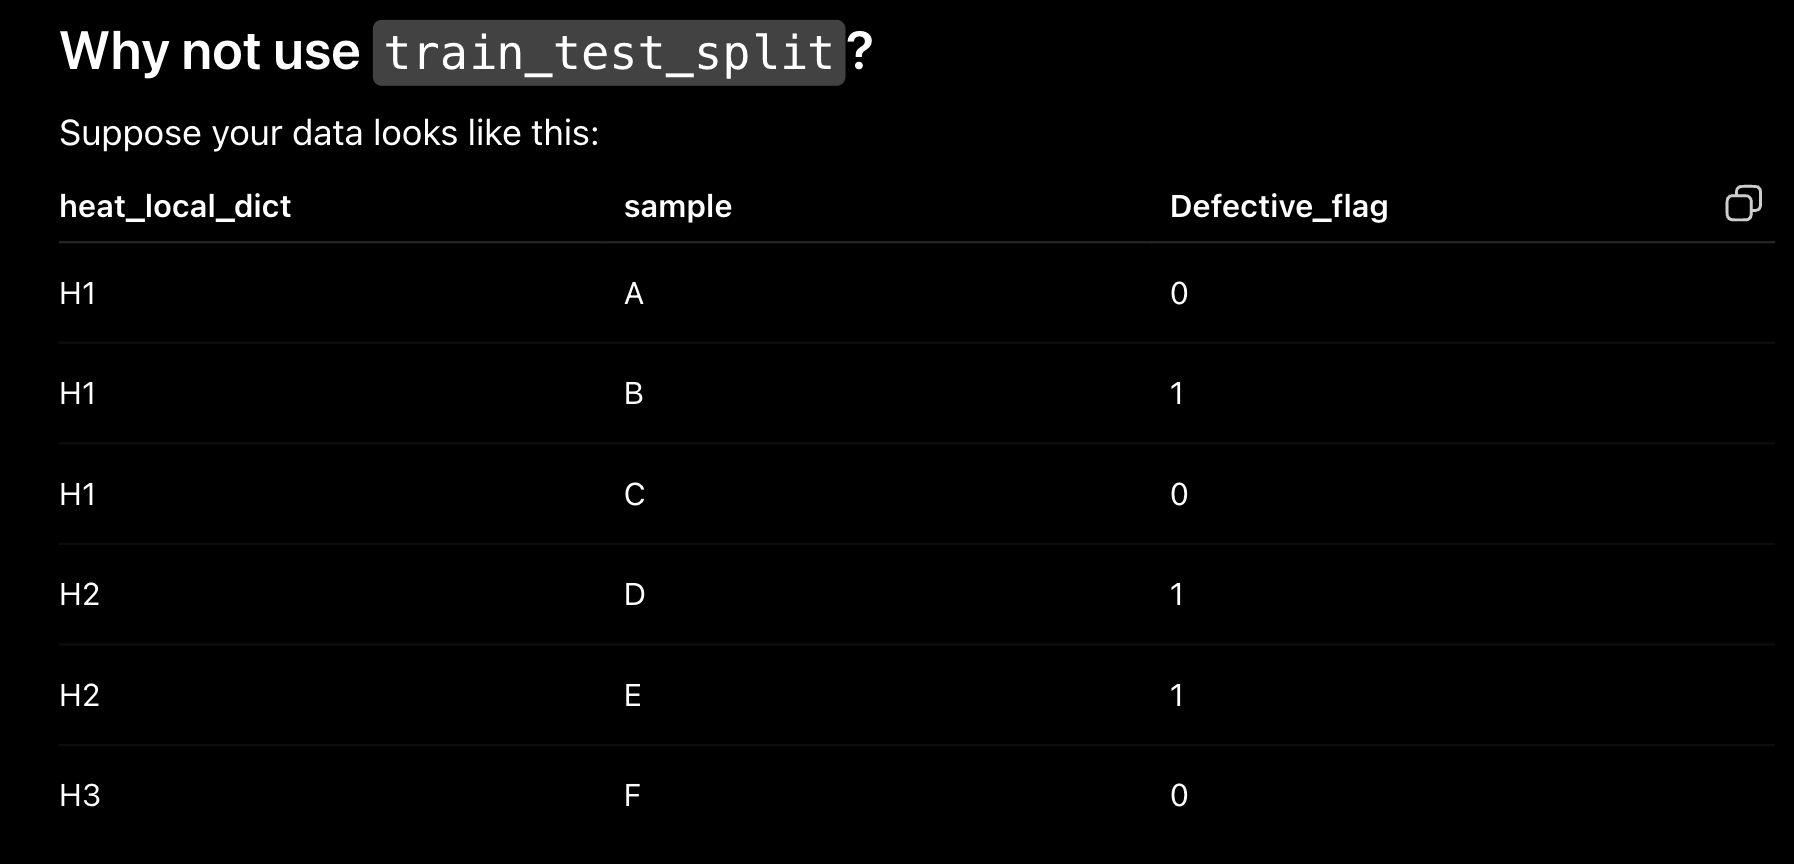

If you use

train_test_split(df_model)

you might get

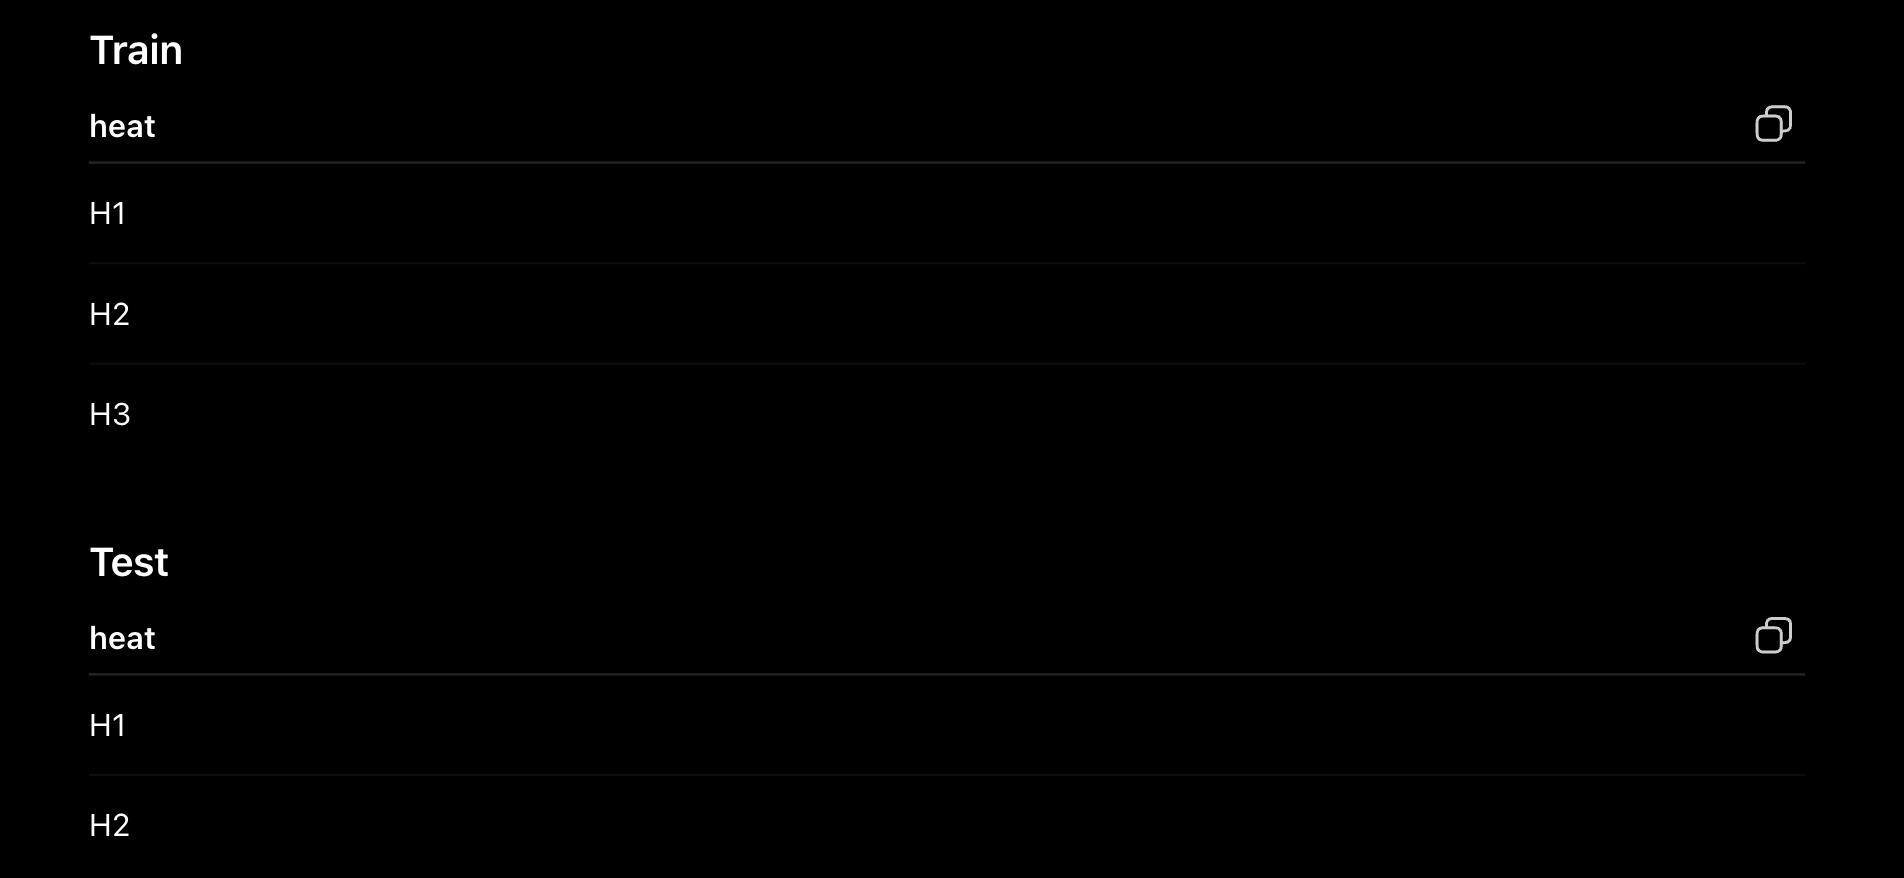


Notice:

H1 is in both train and test.

H2 is also in both.

This is called group leakage.

If rows from the same heat are highly similar, the model has effectively seen information from the test heat during training, making evaluation overly optimistic.

## GroupShuffleSplit splits groups, not individual rows.

For example,

Unique heats are

H1
H2
H3
H4
H5

With

test_size=0.2

20% of groups go into the test set.

Maybe it chooses

Test groups:
H2

Train groups:

H1

H3

H4

H5

Now every row belonging to H2 goes to the test set.

No heat appears in both datasets.

groups = df_model["heat_local_dict"]

Creates the group labels.

Example:

0    H1

1    H1

2    H2

3    H2

4    H2

5    H3

6    H4

Rows with the same value belong to the same group


Creating the splitter

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)


n_splits: Number of different train/test splits to generate.

Example: GroupShuffleSplit(n_splits=5) can generate

Split 1
Split 2
Split 3
Split 4
Split 5

Each split is different.

Since you only need one train/test split,

n_splits=1

is enough.


test_size=0.2: Specifies the fraction of groups (not rows) that go into the test set.

Suppose you have 100 unique heats

Then

20 heats → Test

80 heats → Train

The number of rows may not be exactly 80/20 because different heats can have different numbers of rows.

For example:

Heat A → 500 rows

Heat B → 5 rows

Heat C → 50 rows

The split is based on groups, not row counts.

train_idx, test_idx = next(
    gss.split(
        df_model,
        df_model["Defective_flag"],
        groups=groups
    )
)

Let's examine the parameters to split.

groups=groups: This is the key argument.

It tells the splitter:"Treat rows with the same heat_local_dict as one indivisible unit."

For example,

Row 1 → Heat H1

Row 2 → Heat H1

Row 3 → Heat H2

Row 4 → Heat H2

The splitter ensures:

Either all H1 rows go to train or all H1 rows go to test.
Either all H2 rows go to train or all H2 rows go to test


train_idx and test_idx are arrays of row indices.

For example,

train_idx

[0,1,2,5,6,7]

test_idx

[3,4,8,9]

Using .iloc selects those rows:

train_df = df_model.iloc[train_idx]




train_idx, test_idx = next(
    gss.split(
        df_model,
        df_model["Defective_flag"],
        groups=groups
    )
)


Why next()?

The split() method returns an iterator that can produce multiple splits (up to n_splits).

Conceptually:

for train_idx, test_idx in gss.split(...):
    ...

Since you only requested one split (n_splits=1), next() retrieves that first (and only) pair of indices

gss = GroupShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=42
)

Here, gss.split(...) doesn't return one split. It returns an iterator that can produce 5 different train/test splits.

Conceptually, it's like this:

iterator = gss.split(df_model, groups=groups)

# Split 1
train_idx1, test_idx1

# Split 2
train_idx2, test_idx2

# Split 3
train_idx3, test_idx3

# Split 4
train_idx4, test_idx4

# Split 5
train_idx5, test_idx5




What does next() do?

next() simply asks the iterator:

"Give me the next available split."
So,

train_idx, test_idx = next(gss.split(df_model, groups=groups))

returns only the first split.




## Q How do you access the other splits?

Instead of next(), iterate over them:

for i, (train_idx, test_idx) in enumerate(
    gss.split(df_model, groups=groups)
):
    print(f"Split {i+1}")
    print("Train size:", len(train_idx))
    print("Test size:", len(test_idx))

Output might look like:

Split 1
Train size: 8000
Test size: 2000

Split 2
Train size: 7950
Test size: 2050

Split 3
...

Each split uses a different random selection of groups.

## Summary

groups: Defines which rows belong together (same heat_local_dict).

n_splits=1: Generate one train/test split.

test_size=0.2: Put about 20% of the unique groups into the test set.

random_state=42: Make the random split reproducible.

split(X, y, groups): Returns train and test row indices while ensuring each group appears in only one of the two sets.

next(): Retrieves the first split from the iterator.



In [3]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd

df = pd.DataFrame({
    "heat_local_dict": ["H1","H1","H2","H2","H2","H3","H3","H4","H4","H4"],
    "temperature": [100,102,98,97,99,105,106,95,94,96],
    "Defective_flag": [0,1,0,0,1,1,0,0,1,0]
})

print(df)

  heat_local_dict  temperature  Defective_flag
0              H1          100               0
1              H1          102               1
2              H2           98               0
3              H2           97               0
4              H2           99               1
5              H3          105               1
6              H3          106               0
7              H4           95               0
8              H4           94               1
9              H4           96               0


In [4]:
from sklearn.model_selection import GroupShuffleSplit

groups = df["heat_local_dict"]

gss = GroupShuffleSplit(
    n_splits=2,
    test_size=0.25,
    random_state=42
)

Here,Total groups = 4

Test size = 25%

So each split will place 1 heat into the test set.

In [5]:
for i, (train_idx, test_idx) in enumerate(gss.split(df, groups=groups), start=1):

    print(f"\n===== Split {i} =====")

    print("Train indices:", train_idx)
    print("Test indices :", test_idx)

    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    print("\nTrain heats:")
    print(train_df["heat_local_dict"].unique())

    print("\nTest heats:")
    print(test_df["heat_local_dict"].unique())


===== Split 1 =====
Train indices: [0 1 5 6 7 8 9]
Test indices : [2 3 4]

Train heats:
['H1' 'H3' 'H4']

Test heats:
['H2']

===== Split 2 =====
Train indices: [0 1 5 6 7 8 9]
Test indices : [2 3 4]

Train heats:
['H1' 'H3' 'H4']

Test heats:
['H2']


In [9]:
gss = GroupShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=42
)


train_idx,test_idx=next(gss.split(df,groups=groups))
print(f"\n===== Split {i} =====")
print("Train indices:", train_idx)
print("Test indices :", test_idx)

train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

print("\nTrain heats:")
print(train_df["heat_local_dict"].unique())

print("\nTest heats:")
print(test_df["heat_local_dict"].unique())


===== Split 2 =====
Train indices: [0 1 5 6 7 8 9]
Test indices : [2 3 4]

Train heats:
['H1' 'H3' 'H4']

Test heats:
['H2']
